# 03 — Exploratory analysis

**Input:** `data/processed/interactions_clean.parquet` (474,011 rows, 12,119 students, 5 skills)
**Output:** figures in `results/figures/` (300 dpi) and a dataset summary table

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))
PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

BLUE, RED, GREY = "#4C72B0", "#C44E52", "#7F7F7F"

df = pd.read_parquet(PROCESSED / "interactions_clean.parquet")

SKILLS = [
    "Addition and Subtraction Fractions",
    "Multiplication Fractions",
    "Division Fractions",
    "Equation Solving Two or Fewer Steps",
    "Equation Solving More Than Two Steps",
]
SHORT = {
    "Addition and Subtraction Fractions": "Add/Sub\nFractions",
    "Multiplication Fractions": "Mult\nFractions",
    "Division Fractions": "Div\nFractions",
    "Equation Solving Two or Fewer Steps": "Equations\n<=2 steps",
    "Equation Solving More Than Two Steps": "Equations\n>2 steps",
}

print(f"{len(df):,} rows | {df['user_id'].nunique():,} students | {df['skill'].nunique()} skills")

474,011 rows | 12,119 students | 5 skills


## 3.1 Dataset summary

In [2]:
pairs = df.groupby(["user_id", "skill"], observed=True)
seq_len = pairs["opportunity"].max()

desc = pd.DataFrame([
    ("Interactions", f"{len(df):,}"),
    ("Students", f"{df['user_id'].nunique():,}"),
    ("Skills (knowledge components)", f"{df['skill'].nunique()}"),
    ("Student-skill sequences", f"{len(seq_len):,}"),
    ("Median sequence length", f"{seq_len.median():.0f}"),
    ("Mean sequence length", f"{seq_len.mean():.1f}"),
    ("Distinct problems", f"{df['problem_id'].nunique():,}"),
    ("First-attempt accuracy", f"{df['correct'].mean():.3f}"),
    ("Interactions with >=1 hint", f"{(df['hint_count'] > 0).mean():.1%}"),
    ("Mean attempts per problem", f"{df['attempt_count'].mean():.2f}"),
    ("Median response time (s)", f"{df['ms_first_response'].median()/1000:.1f}"),
    ("Date range", f"{df['start_time'].min():%b %Y} to {df['start_time'].max():%b %Y}"),
], columns=["Measure", "Value"])

desc.to_csv(PROCESSED / "dataset_description.csv", index=False)
desc

,Measure,Value
0,Interactions,"474,011"
1,Students,"12,119"
2,Skills (knowledge components),5
3,Student-skill sequences,"23,755"
4,Median sequence length,12
5,Mean sequence length,20.0
6,Distinct problems,"7,855"
7,First-attempt accuracy,0.681
8,Interactions with >=1 hint,17.1%
9,Mean attempts per problem,1.37


## 3.2 Practice per student

How much data there is per student, and how long the practice sequences are.

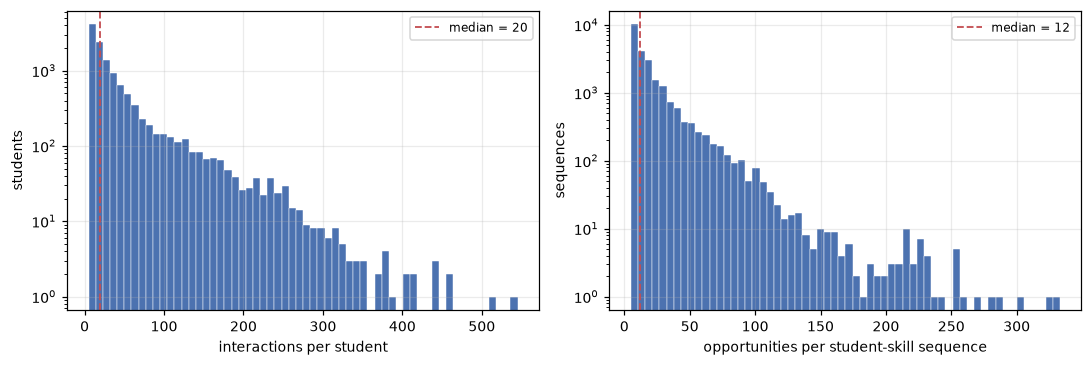

interactions per student : median 20, IQR 10-44, max 545
sequence length          : median 12, IQR 8-23, max 333


In [3]:
per_student = df.groupby("user_id").size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

ax1.hist(per_student, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
ax1.set_xlabel("interactions per student")
ax1.set_ylabel("students")
ax1.set_yscale("log")
ax1.axvline(per_student.median(), color=RED, ls="--", lw=1.2,
            label=f"median = {per_student.median():.0f}")
ax1.legend(fontsize=8)

ax2.hist(seq_len, bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
ax2.set_xlabel("opportunities per student-skill sequence")
ax2.set_ylabel("sequences")
ax2.set_yscale("log")
ax2.axvline(seq_len.median(), color=RED, ls="--", lw=1.2,
            label=f"median = {seq_len.median():.0f}")
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "fig_4_1_practice_volume.png", bbox_inches="tight")
plt.show()

print(f"interactions per student : median {per_student.median():.0f}, "
      f"IQR {per_student.quantile(.25):.0f}-{per_student.quantile(.75):.0f}, "
      f"max {per_student.max():,}")
print(f"sequence length          : median {seq_len.median():.0f}, "
      f"IQR {seq_len.quantile(.25):.0f}-{seq_len.quantile(.75):.0f}, "
      f"max {seq_len.max():,}")

Both distributions are strongly right-skewed, so medians are used for per-student summaries.

## 3.3 Spread of student ability

Mean first-attempt accuracy per student (students with at least 20 interactions), to see how widely ability varies.

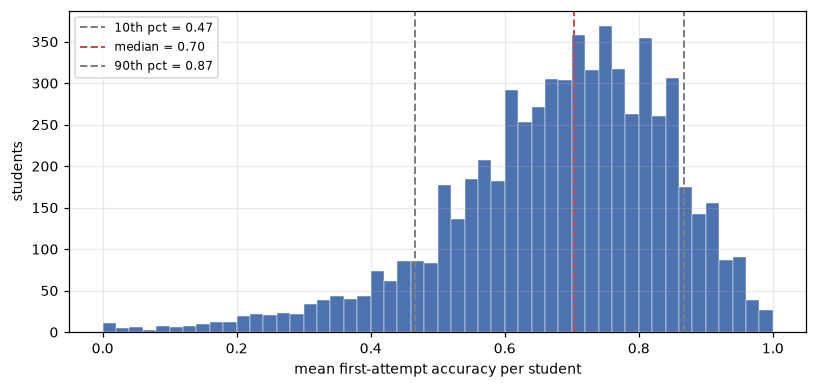

students with >= 20 interactions: 6,352
10th-90th percentile accuracy range: 0.467 to 0.867 (a spread of 0.401)

In a class of 40 drawn from this population, the weakest and strongest
students differ by roughly 40 percentage points in accuracy
on the same material. That is the problem EATS exists to address.


In [4]:
student_acc = df.groupby("user_id")["correct"].agg(["mean", "size"])
student_acc = student_acc[student_acc["size"] >= 20]  # stable estimates only

p10, p50, p90 = student_acc["mean"].quantile([.10, .50, .90])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(student_acc["mean"], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
for v, lab, c in [(p10, f"10th pct = {p10:.2f}", GREY),
                  (p50, f"median = {p50:.2f}", RED),
                  (p90, f"90th pct = {p90:.2f}", GREY)]:
    ax.axvline(v, color=c, ls="--", lw=1.3, label=lab)
ax.set_xlabel("mean first-attempt accuracy per student")
ax.set_ylabel("students")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_2_ability_spread.png", bbox_inches="tight")
plt.show()

print(f"students with >= 20 interactions: {len(student_acc):,}")
print(f"10th-90th percentile accuracy range: {p10:.3f} to {p90:.3f} "
      f"(a spread of {p90-p10:.3f})")
print(f"\nIn a class of 40 drawn from this population, the weakest and strongest")
print(f"students differ by roughly {100*(p90-p10):.0f} percentage points in accuracy")
print("on the same material. That is the problem EATS exists to address.")

## 3.4 Response time

Raw response times have a very long tail, which is why notebook 04 uses a log transform and clips at the 99th percentile. The plots show the data before and after.

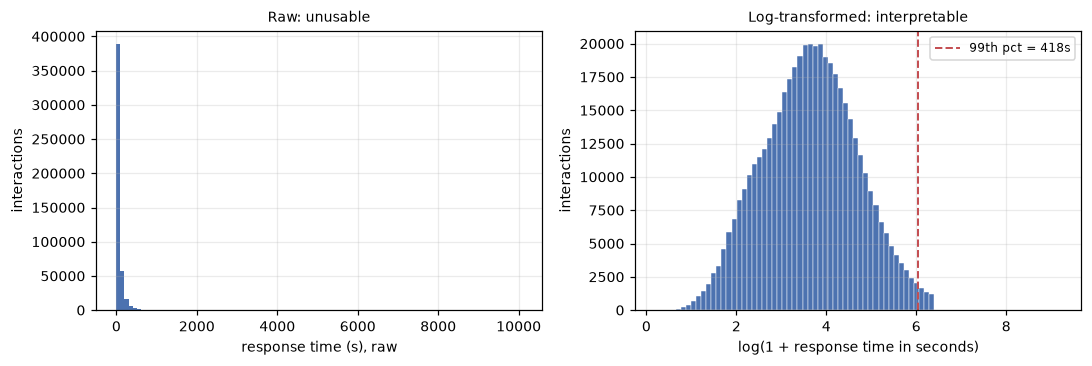

response time percentiles (seconds):
  p 50.0          37.8
  p 75.0          78.2
  p 90.0         149.3
  p 95.0         220.6
  p 99.0         418.5
  p 99.9         576.6
  max         10,080.0   (2.8 hours)

The maximum is 267x the median. Those are not slow
students - they are students who left the tab open. Hence clipping.


In [5]:
rt = df["ms_first_response"] / 1000  # seconds
p99 = rt.quantile(0.99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

ax1.hist(rt, bins=100, color=BLUE)
ax1.set_xlabel("response time (s), raw")
ax1.set_ylabel("interactions")
ax1.set_title("Raw: unusable", fontsize=9)

ax2.hist(np.log1p(rt), bins=80, color=BLUE, edgecolor="white", linewidth=0.3)
ax2.axvline(np.log1p(p99), color=RED, ls="--", lw=1.3,
            label=f"99th pct = {p99:,.0f}s")
ax2.set_xlabel("log(1 + response time in seconds)")
ax2.set_ylabel("interactions")
ax2.set_title("Log-transformed: interpretable", fontsize=9)
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "fig_4_3_response_time.png", bbox_inches="tight")
plt.show()

qs = rt.quantile([.5, .75, .9, .95, .99, .999])
print("response time percentiles (seconds):")
for q, v in qs.items():
    print(f"  p{q*100:>5.1f}  {v:>12,.1f}")
print(f"  max     {rt.max():>12,.1f}   ({rt.max()/3600:,.1f} hours)")
print(f"\nThe maximum is {rt.max()/qs[0.5]:,.0f}x the median. Those are not slow")
print("students - they are students who left the tab open. Hence clipping.")

The ratio of the maximum to the median response time shows how extreme the tail is.

## 3.5 Hints and attempts

`hint_count` and `attempt_count` feed two of the four state features (hint rate and error pattern).

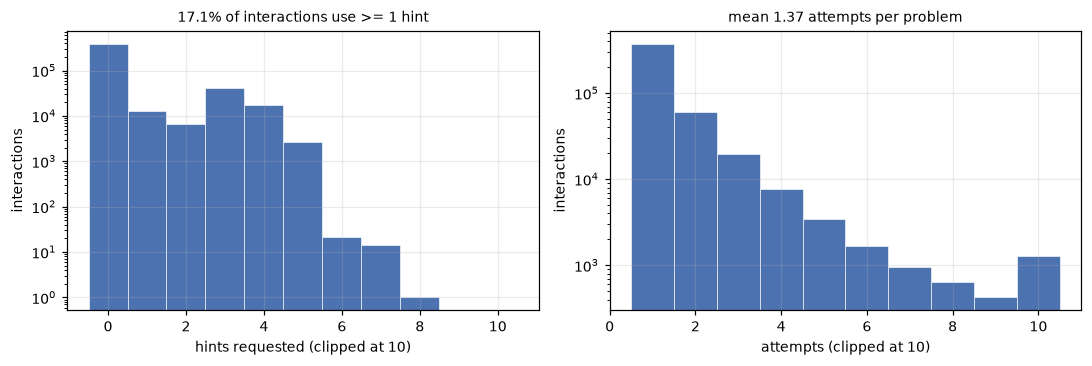

hint usage when the answer was WRONG vs RIGHT:
         mean_hints  pct_using_hints
correct                             
0.0           1.549            0.536
1.0           0.000            0.000


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

hc = df["hint_count"].clip(upper=10)
ax1.hist(hc, bins=np.arange(-0.5, 11.5), color=BLUE, edgecolor="white", linewidth=0.4)
ax1.set_xlabel("hints requested (clipped at 10)")
ax1.set_ylabel("interactions")
ax1.set_yscale("log")
ax1.set_title(f"{(df['hint_count'] > 0).mean():.1%} of interactions use >= 1 hint",
              fontsize=9)

ac = df["attempt_count"].clip(upper=10)
ax2.hist(ac, bins=np.arange(0.5, 11.5), color=BLUE, edgecolor="white", linewidth=0.4)
ax2.set_xlabel("attempts (clipped at 10)")
ax2.set_ylabel("interactions")
ax2.set_yscale("log")
ax2.set_title(f"mean {df['attempt_count'].mean():.2f} attempts per problem", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / "fig_4_4_help_and_persistence.png", bbox_inches="tight")
plt.show()

print("hint usage when the answer was WRONG vs RIGHT:")
print(df.groupby("correct")["hint_count"].agg(
    ["mean", lambda s: (s > 0).mean()]
).rename(columns={"mean": "mean_hints", "<lambda_0>": "pct_using_hints"}).round(3).to_string())

Hint usage differs a lot between correct and incorrect answers. No correct answer has a hint, because requesting a hint marks the item incorrect.

## 3.6 The five skills compared

Accuracy, hint usage, practice depth and student count for each selected skill.

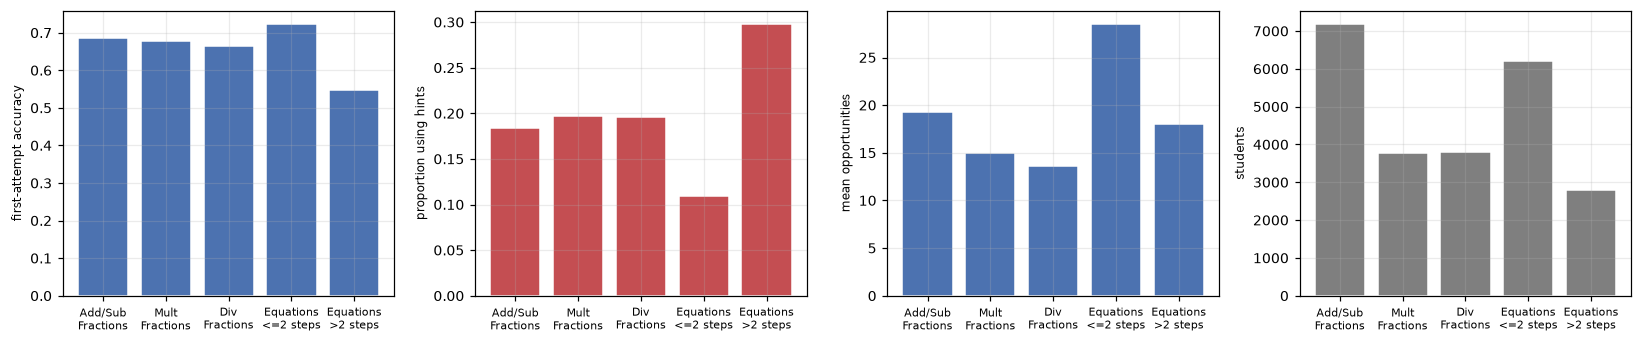

,interactions,students,accuracy,hint_rate,mean_attempts,mean_seq_len
skill,,,,,,
Addition and Subtraction Fractions,138201,7179,0.685,0.184,1.407,19.251
Multiplication Fractions,56442,3763,0.677,0.197,1.402,14.999
Division Fractions,51874,3797,0.664,0.196,1.399,13.662
Equation Solving Two or Fewer Steps,176819,6207,0.723,0.109,1.305,28.487
Equation Solving More Than Two Steps,50675,2809,0.547,0.298,1.392,18.040


In [7]:
by_skill = (
    df.groupby("skill", observed=True)
    .agg(
        interactions=("correct", "size"),
        students=("user_id", "nunique"),
        accuracy=("correct", "mean"),
        hint_rate=("hint_count", lambda s: (s > 0).mean()),
        mean_attempts=("attempt_count", "mean"),
    )
    .reindex(SKILLS)
)
by_skill["mean_seq_len"] = (
    seq_len.reset_index().groupby("skill", observed=True)["opportunity"].mean().reindex(SKILLS)
)
by_skill.to_csv(PROCESSED / "skill_comparison.csv")

labels = [SHORT[s] for s in SKILLS]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
panels = [
    ("accuracy", "first-attempt accuracy", BLUE),
    ("hint_rate", "proportion using hints", RED),
    ("mean_seq_len", "mean opportunities", BLUE),
    ("students", "students", GREY),
]
for ax, (col, ylab, colour) in zip(axes, panels):
    ax.bar(range(5), by_skill[col], color=colour, edgecolor="white")
    ax.set_xticks(range(5))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel(ylab, fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / "fig_4_5_skill_comparison.png", bbox_inches="tight")
plt.show()

by_skill.round(3)

## 3.7 Learning curves with confidence intervals

Later opportunities are based on fewer students, so the curves show 95% intervals (normal approximation, `1.96 * sqrt(p(1-p)/n)`). Only opportunities with at least 50 observations are plotted.

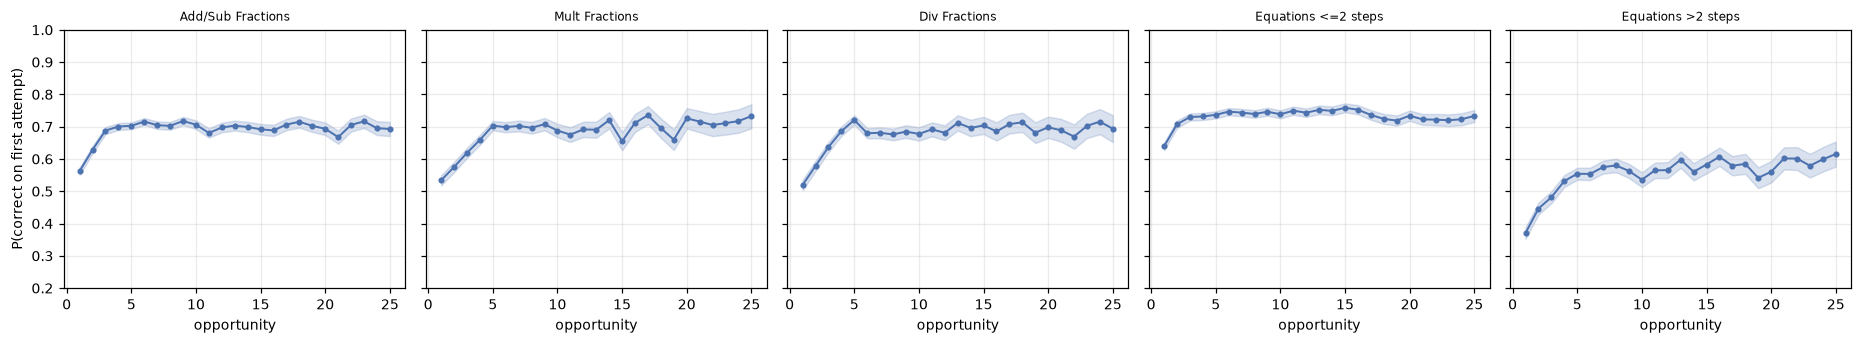

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.2), sharey=True)
MAX_OPP, MIN_N = 25, 50

for ax, skill in zip(axes, SKILLS):
    sub = df[df["skill"] == skill]
    c = sub.groupby("opportunity")["correct"].agg(["mean", "size"])
    c = c[(c.index <= MAX_OPP) & (c["size"] >= MIN_N)]
    err = 1.96 * np.sqrt(c["mean"] * (1 - c["mean"]) / c["size"])

    ax.plot(c.index, c["mean"], "o-", ms=3, lw=1.3, color=BLUE)
    ax.fill_between(c.index, c["mean"] - err, c["mean"] + err, alpha=0.2, color=BLUE)
    ax.set_ylim(0.2, 1.0)
    ax.set_xlabel("opportunity")
    ax.set_title(SHORT[skill].replace("\n", " "), fontsize=8)

axes[0].set_ylabel("P(correct on first attempt)")
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_6_learning_curves.png", bbox_inches="tight")
plt.show()

## 3.8 Correlations between the raw signals

If the signals behind the four features were strongly correlated, some features would be redundant.

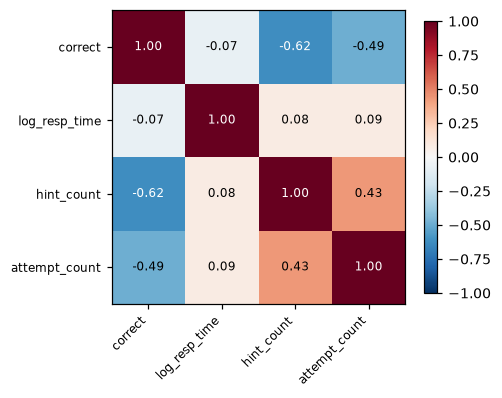

,correct,log_resp_time,hint_count,attempt_count
correct,1.000,-0.074,-0.618,-0.487
log_resp_time,-0.074,1.000,0.080,0.085
hint_count,-0.618,0.080,1.000,0.434
attempt_count,-0.487,0.085,0.434,1.000


In [9]:
sig = pd.DataFrame({
    "correct": df["correct"],
    "log_resp_time": np.log1p(df["ms_first_response"] / 1000),
    "hint_count": df["hint_count"],
    "attempt_count": df["attempt_count"],
})
corr = sig.corr()

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
ax.grid(False)
fig.colorbar(im, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_7_signal_correlations.png", bbox_inches="tight")
plt.show()

corr.round(3)

## 3.9 Saved figures

In [10]:
figs = sorted(FIGURES.glob("*.png"))
print(f"{len(figs)} figures in {FIGURES}\n")
for f in figs:
    print(f"  {f.name:<42} {f.stat().st_size/1000:>7.0f} KB")

print("\nAll figures saved at 300 dpi.")

8 figures in C:\Users\vedac\Desktop\EATS\results\figures

  empirical_learning_curves.png                  164 KB
  fig_4_1_practice_volume.png                     79 KB
  fig_4_2_ability_spread.png                      69 KB
  fig_4_3_response_time.png                      110 KB
  fig_4_4_help_and_persistence.png                85 KB
  fig_4_5_skill_comparison.png                   165 KB
  fig_4_6_learning_curves.png                    289 KB
  fig_4_7_signal_correlations.png                 87 KB

All figures saved at 300 dpi.
